# <font color = 'indianred'>**Multilabel Classification of StackExchange Dataset using GEMMA** </font>

**Objective:**

In this notebook, we aim to use GEMMA models with QLORA for classification problems.


**Plan**

1. Set Environment
2. Load Dataset
3. Accessing and Manipulating Splits
4. Load Pre-trained Tokenizer
5. Create Function for Tokenizer
4. Train Model
  1. Download pre-trained model <br>
  2. Download and modify the model config file <br>
  3. Compute Metric Function <br>
  4. Training Arguments <br>
  5. Instantiate Trainer <br>
  6. Setup WandB <br>
  7. Training and Validation
6. Perfromance on Test Set
7. Model Inference






















# <font color = 'indianred'> **1. Setting up the Environment** </font>



In [1]:
# If in Colab, then import the drive module from google.colab
if 'google.colab' in str(get_ipython()):
  !pip install numpy -U -qq
  !pip install transformers evaluate wandb datasets accelerate trl peft bitsandbytes  -U -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 119.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.5 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

 <Font size = 5 color = 'indianred'>**Restart the session before moving onto next cell**
> Runtime- Restart Session

<font color = 'indianred'> *Load Libraries* </font>

In [1]:
# standard data science librraies for data handling and v isualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import gc
import time

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import multilabel_confusion_matrix, precision_score, recall_score, f1_score
import joblib

import torch
import torch.nn as nn
import ast


# New libraries introduced in this notebook
import evaluate
from datasets import load_dataset, DatasetDict, Dataset, ClassLabel
from transformers import (
    TrainingArguments,
    Trainer,
    set_seed,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    pipeline,
    BitsAndBytesConfig,
)

from trl import SFTTrainer
from peft import (
    TaskType,
    LoraConfig,
    prepare_model_for_kbit_training,
    get_peft_model,
    AutoPeftModelForSequenceClassification,
    PeftConfig
)
import wandb
from google.colab import userdata
from huggingface_hub import login, HfApi, create_repo

In [2]:
wandb_api_key = userdata.get('WANDB_API_KEY')
hf_token = userdata.get('HF_TOKEN')


In [3]:
if hf_token:
    # Log in to Hugging Face
    login(token=hf_token)
    print("Successfully logged in to Hugging Face!")
else:
    print("Hugging Face token not found in notebook secrets.")


Successfully logged in to Hugging Face!


In [4]:
if wandb_api_key:
  wandb.login(key=wandb_api_key)
  print("Successfully logged in to WANDB!")
else:
    print("WANDB key not found in notebook secrets.")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: younes-hoseini67 (younes-hoseini67-university-of-texas-at-dallas) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Successfully logged in to WANDB!


# <font color = 'indianred'> **2. Load Data set**
    


In [5]:
# Determine the storage location based on the execution environment
# If running on Google Colab, use Google Drive as storage
# CHANGE FOLDERS TO WHERE YOU WANT TO SAVE DATA AND MODELS

if 'google.colab' in str(get_ipython()):
    from google.colab import drive  # Import Google Drive mounting utility
    drive.mount('/content/drive')  # Mount Google Drive

    # Set base folder path for storing data on Google Drive
    base_folder= Path('/content/drive/MyDrive')

# If running locally, specify a different path
else:
    # Set base folder path for storing data on local machine
    base_folder= Path('/home/harpreet/Insync/google_drive_shaannoor/data')

Mounted at /content/drive


In [6]:
kaggle_api = base_folder/'.kaggle'
import os
if 'google.colab' in str(get_ipython()):
    os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/MyDrive/.kaggle/"
if 'google.colab' in str(get_ipython()):
    !chmod 600 /content/drive/MyDrive/.kaggle/kaggle.json
if 'google.colab' in str(get_ipython()):
    ! ls -la  /content/drive/MyDrive/.kaggle/kaggle.json

-rw------- 1 root root 67 Oct 27 23:03 /content/drive/MyDrive/.kaggle/kaggle.json


In [7]:
data_folder = base_folder/'emotion_detection'


In [8]:
data_folder.mkdir(exist_ok=True)
kaggle_api.mkdir(exist_ok=True)

In [9]:
!kaggle competitions download -c emotion-detection-fall-2025-dl
!unzip -o emotion-detection-fall-2025-dl.zip -d {data_folder}

  0% 0.00/609k [00:00<?, ?B/s]
100% 609k/609k [00:00<00:00, 1.14GB/s]
Archive:  emotion-detection-fall-2025-dl.zip
  inflating: /content/drive/MyDrive/emotion_detection/sample_submission.csv  
  inflating: /content/drive/MyDrive/emotion_detection/test.csv  
  inflating: /content/drive/MyDrive/emotion_detection/train.csv  


In [10]:
train = pd.read_csv(data_folder/'train.csv')
print(f"Kaggle train data shape: {train.shape}")
print(f"Columns: {train.columns.tolist()}")

# Use the Kaggle training data
df = train
df

Kaggle train data shape: (7724, 13)
Columns: ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']


,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
0,2017-21441,“Worry is a down payment on a problem you may ...,0,1,0,0,0,0,1,0,0,0,1
1,2017-31535,Whatever you decide to do make sure it makes y...,0,0,0,0,1,1,1,0,0,0,0
2,2017-21068,@Max_Kellerman it also helps that the majorit...,1,0,1,0,1,0,1,0,0,0,0
3,2017-31436,Accept the challenges so that you can literall...,0,0,0,0,1,0,1,0,0,0,0
4,2017-22195,My roommate: it's okay that we can't spell bec...,1,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7719,2018-01993,@BadHombreNPS @SecretaryPerry If this didn't m...,1,0,1,0,0,0,0,0,0,0,0
7720,2018-01784,Excited to watch #stateoforigin tonight! Come ...,0,0,0,0,1,0,1,0,0,0,0
7721,2018-04047,"Blah blah blah Kyrie, IT, etc. @CJC9BOSS leavi...",1,0,1,0,0,0,0,0,1,0,0
7722,2018-03041,#ThingsIveLearned The wise #shepherd never tru...,0,0,0,0,0,0,0,0,0,0,0


In [11]:
stack_dataset = Dataset.from_pandas(df)

In [12]:
class_names = ['anger', 'anticipation', 'disgust', 'fear', 'joy',
               'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
emotion_dataset = Dataset.from_pandas(df)
selected_columns = {
    'text': emotion_dataset['Tweet'],
    'emotion_labels': [[emotion for emotion in class_names if row[emotion] == 1]
                       for row in emotion_dataset]}
# Create a new dataset with the selected columns
emotion_selected_columns = Dataset.from_dict(selected_columns)

emotion_selected_columns.set_format(type='pandas')
df = emotion_selected_columns[:]

# Apply MultiLabelBinarizer to convert emotion label lists to binary vectors
label_encoder = MultiLabelBinarizer()
label_encoder.fit([class_names])  # Fit on all possible emotion classes
df['label'] = list(label_encoder.transform(df['emotion_labels']))

# Create final dataframe with text and label
df_final = df[['text', 'label']]

df_final['label'][0:2]



,label
0,"[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1]"
1,"[0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0]"


In [13]:
stack_selected_columns_final = Dataset.from_pandas(df_final)

In [14]:
emotion_dataset = Dataset.from_pandas(df_final)

# <font color = 'indianred'> **3. Accessing and Manuplating Splits**</font>



<font color = 'indianred'>*Create futher subdivions of the splits*</font>

In [15]:
# Split the test set into test and validation sets
test_val_splits = stack_selected_columns_final.train_test_split(test_size=0.4, seed=42)
train_split= test_val_splits['train']
test_val_splits = test_val_splits['test'].train_test_split(test_size=0.5, seed=42,)
val_split = test_val_splits['train']
test_split = test_val_splits['test']


<font color = 'indianred'>*small subset for initial experimenttaion*</font>

In [16]:
train_split = train_split.shuffle(seed = 42).select(range(min(2000, len(train_split))))
val_split = val_split.shuffle(seed = 42).select(range(min(2000, len(val_split))))
test_split = test_split.shuffle(seed = 42).select(range(min(2000, len(test_split))))

In [17]:
train_val_subset= DatasetDict(
    {"train": train_split, "valid": val_split})

In [18]:
train_val_subset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    valid: Dataset({
        features: ['text', 'label'],
        num_rows: 1545
    })
})

In [19]:
train_val_subset['train']['label'][0]

[1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0]

# <font color = 'indianred'>**4. Load pre-trained Tokenizer**</font>



In [20]:
def free_gpu_memory():
    """
    Frees up GPU memory after CUDA out-of-memory error in Colab.

    This function performs the following steps:
    1. Deletes all PyTorch objects to clear references.
    2. Calls garbage collection to remove unreferenced objects from memory.
    3. Uses torch.cuda.empty_cache() to release cached GPU memory.
    4. Waits for a moment to ensure memory is fully released.
    """
    try:
        # Delete all torch tensors to free up memory
        for obj in list(locals().values()):
            if torch.is_tensor(obj):
                del obj

        # Collect garbage to release any remaining unused memory
        gc.collect()

        # Empty the CUDA cache to release GPU memory
        torch.cuda.empty_cache()

        # Adding a small delay to allow memory to be fully released
        time.sleep(2)

        print("GPU memory has been freed.")
    except Exception as e:
        print(f"Error while freeing GPU memory: {e}")


In [21]:
free_gpu_memory()

GPU memory has been freed.


In [22]:
checkpoint = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

#<font color = 'indianred'> **5. Create function for Tokenizer**



In [23]:
def tokenize_fn(batch):
    return tokenizer(text = batch["text"], truncation=True, max_length=512)

<font color = 'indianred'> *Use map function to apply tokenization to all splits*

In [24]:
tokenized_dataset= train_val_subset.map(tokenize_fn, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(
    ['text']
)
tokenized_dataset.set_format(type='torch')

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1545 [00:00<?, ? examples/s]

In [25]:
tokenized_dataset = (tokenized_dataset
          .map(lambda x : {"float_label": x["label"].to(torch.float)}, remove_columns=["label"])
          .rename_column("float_label", "label"))

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1545 [00:00<?, ? examples/s]

In [26]:
tokenized_dataset['train']['label'][0:3]

tensor([[1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.]])

#  <font color = 'indianred'> **6. Model Training**

##  <font color = 'indianred'> **6.1 Download pre-trained model**

In [27]:
def get_appropriate_dtype():
    if torch.cuda.is_available() and torch.cuda.get_device_capability(0) >= (8, 0):
        return torch.bfloat16
    return torch.float16

In [28]:
torch_data_type = get_appropriate_dtype()
torch_data_type

torch.bfloat16

In [29]:
bnb_config = BitsAndBytesConfig(
  load_in_4bit=True,
  bnb_4bit_quant_type="nf4",
  bnb_4bit_use_double_quant=True,
  bnb_4bit_compute_dtype=torch_data_type,
  bnb_4bit_quant_storage=torch_data_type,
)

In [30]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint,
                                                           num_labels = 11,
                                                           problem_type="multi_label_classification",
                                                           quantization_config=bnb_config,
                                                           torch_dtype=torch_data_type,
                                                           trust_remote_code=True,)


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/481M [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some weights of Gemma2ForSequenceClassification were not initialized from the model checkpoint at google/gemma-2-2b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
model

Gemma2ForSequenceClassification(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear4bit(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear4bit(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
      

##  <font color = 'indianred'> **6.2 Downaload and Modify Model Config File**

In [32]:
config = AutoConfig.from_pretrained(checkpoint)
id2label= {id_: label_ for id_, label_ in enumerate(class_names)}
label2id = {label_: id_ for id_, label_ in enumerate(class_names)}
config.id2label = id2label
config.label2id = label2id
model.config = config


##  <font color = 'indianred'> **6.3 PEFT Setup**

In [33]:
model

Gemma2ForSequenceClassification(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear4bit(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear4bit(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear4bit(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
      

In [34]:
def find_linear_layers(model):
    """
    Extracts the unique names of Linear layers from a model.

    Args:
    model (nn.Module): The model from which to extract Linear layer names.

    Returns:
    list: A list of unique names of Linear layers.
    """
    # Convert the model's modules to string
    model_modules = str(model.modules)
    # Pattern to extract names of Linear layers
    pattern = r'\((\w+)\): Linear'
    # Find all occurrences of the pattern
    linear_layer_names = re.findall(pattern, model_modules)
    print(linear_layer_names)
    # Get unique names using a set, then convert back to list
    target_modules = list(set(linear_layer_names))
    return target_modules

In [35]:
find_linear_layers(model)

['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj', 'score']


['gate_proj',
 'q_proj',
 'score',
 'up_proj',
 'down_proj',
 'v_proj',
 'k_proj',
 'o_proj']

In [36]:
# LoraConfig??

In [37]:
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=128,
    lora_alpha=256,
    lora_dropout=0.01,
    # bias="lora-only", # Removed this line
    modules_to_save= ['score'],
    target_modules = ['v_proj',  'q_proj',  'up_proj', 'o_proj', 'down_proj', 'gate_proj','k_proj'])

In [38]:
lora_model = get_peft_model(model, peft_config )
# qlora_model.resize_token_embeddings(len(tokenizer))
lora_model.print_trainable_parameters()

trainable params: 166,159,104 || all params: 2,780,526,336 || trainable%: 5.9758


In [39]:
lora_model

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): Gemma2ForSequenceClassification(
      (model): Gemma2Model(
        (embed_tokens): Embedding(256000, 2304, padding_idx=0)
        (layers): ModuleList(
          (0-25): 26 x Gemma2DecoderLayer(
            (self_attn): Gemma2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2304, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.01, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2304, out_features=128, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=128, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleD

In [40]:
for name, param in lora_model.named_parameters():
    print(f"{name}: {param.requires_grad}")


base_model.model.model.embed_tokens.weight: False
base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight: False
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight: True
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight: True
base_model.model.model.layers.0.self_attn.k_proj.base_layer.weight: False
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight: True
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight: True
base_model.model.model.layers.0.self_attn.v_proj.base_layer.weight: False
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight: True
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight: True
base_model.model.model.layers.0.self_attn.o_proj.base_layer.weight: False
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight: True
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight: True
base_model.model.model.layers.0.mlp.ga

##  <font color = 'indianred'> **6.4 compute_metrics function** </font>



In [41]:
# load training metrices
f1 = evaluate.load('f1','multilabel')


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Apply sigmoid to convert logits to probabilities for multilabel
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    # Apply a threshold (e.g., 0.5) to get binary predictions for each label
    predictions = (probs > 0.5).astype(int)

    # Compute multilabel metrics
    f1_macro = f1.compute(predictions=predictions, references=labels, average='macro')['f1']

    return {'f1_macro': f1_macro}


## <font color = 'indianred'> **6.4 Training Arguments**</font>







In [42]:
# Define the directory where model checkpoints will be saved
model_folder = Path("/content/gemma_lora_imb")
# Create the directory if it doesn't exist
model_folder.mkdir(exist_ok=True, parents=True)
run_name= 'stack_exp_ch_gemma_base'

use_fp16 = torch_data_type == torch.float16
use_bf16 = torch_data_type == torch.bfloat16

# Configure training parameters
training_args = TrainingArguments(
    seed = 42,
    # Training-specific configurations
    num_train_epochs=2,  # Total number of training epochs
    # Number of samples per training batch for each device
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    # per_device_train_batch_size=32,
    # per_device_eval_batch_size=32,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant":False},
    # torch_empty_cache_steps=5,
    weight_decay=0.0,  # Apply L2 regularization to prevent overfitting
    learning_rate=1e-5,  # Step size for the optimizer during training
    optim='adamw_torch',  # Optimizer,

    # Checkpoint saving and model evaluation settings
    output_dir=str(model_folder),  # Directory to save model checkpoints
    eval_strategy='steps',  # Evaluate model at specified step intervals
    eval_steps=20,  # Perform evaluation every 10 training steps
    save_strategy="steps",  # Save model checkpoint at specified step intervals
    save_steps=20,  # Save a model checkpoint every 10 training steps
    load_best_model_at_end=True,  # Reload the best model at the end of training
    save_total_limit=2,  # Retain only the best and the most recent model checkpoints
    # Use 'accuracy' as the metric to determine the best model
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,  # A model is 'better' if its accuracy is higher


    # Experiment logging configurations (commented out in this example)
    logging_strategy='steps',
    logging_steps=20,
    report_to='wandb',  # Log metrics and results to Weights & Biases platform
    run_name= run_name,  # Experiment name for Weights & Biases

    # Precision settings determined based on GPU capability
    fp16=use_fp16 ,  # Set True if torch_data_type is torch.float16
    bf16=use_bf16,  # Set True if torch_data_type is torch.bfloat16
    tf32=False,  # Disable tf32 unless you want to use Ampere specific optimization
)


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [43]:
# If gradient checkpointing is enabled, configure relevant settings
if training_args.gradient_checkpointing:
    lora_model.config.use_cache = False  # Disable caching for compatibility

lora_model.config

Gemma2Config {
  "architectures": [
    "Gemma2ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": 50.0,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "dtype": "float32",
  "eos_token_id": 1,
  "final_logit_softcapping": 30.0,
  "head_dim": 256,
  "hidden_act": "gelu_pytorch_tanh",
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 2304,
  "id2label": {
    "0": "anger",
    "1": "anticipation",
    "2": "disgust",
    "3": "fear",
    "4": "joy",
    "5": "love",
    "6": "optimism",
    "7": "pessimism",
    "8": "sadness",
    "9": "surprise",
    "10": "trust"
  },
  "initializer_range": 0.02,
  "intermediate_size": 9216,
  "label2id": {
    "anger": 0,
    "anticipation": 1,
    "disgust": 2,
    "fear": 3,
    "joy": 4,
    "love": 5,
    "optimism": 6,
    "pessimism": 7,
    "sadness": 8,
    "surprise": 9,
    "trust": 10
  },
  "layer_types": [
    "sliding_attention",
    "full_attention",
    "sliding_a

##  <font color = 'indianred'> **6.5 Initialize Trainer**</font>



In [44]:
def calculate_pos_weights(dataset):
    # Initialize counters for all labels
    num_labels = len(dataset['train']['label'][0])
    total_positives = [0] * num_labels
    total_negatives = [0] * num_labels

    # Count positives and negatives for each label
    for label_array in dataset['train']['label']:
        for i, label in enumerate(label_array):
            if label == 1:
                total_positives[i] += 1
            else:
                total_negatives[i] += 1

    # Calculate pos_weight for each label
    pos_weight = [total_negatives[i] / max(total_positives[i], 1) for i in range(num_labels)]
    return torch.tensor(pos_weight)

In [45]:
pos_weights = calculate_pos_weights(tokenized_dataset)

In [46]:
pos_weights

tensor([ 1.5641,  5.7568,  1.5674,  4.7471,  1.7322,  8.4340,  2.3784,  7.7719,
         2.2415, 20.7391, 20.5054])

In [47]:
# initialize trainer
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").float()  # Ensure labels are float for BCE loss
        outputs = model(**inputs)
        logits = outputs.get("logits")

        device = next(model.parameters()).device

        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [48]:
# lora_model.config.use_cache = False
trainer = CustomTrainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["valid"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)

/tmp/ipython-input-2515851054.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  trainer = CustomTrainer(


## <font color = 'indianred'> **6.6 Setup WandB**</font>

In [49]:
%env WANDB_PROJECT = emotion-detection

env: WANDB_PROJECT=emotion-detection


##  <font color = 'indianred'> **6.7 Training and Validation**

In [50]:
try:
    # Your code that may cause a CUDA out-of-memory error
    # Example: trainer.train() or other GPU intensive operations
    # lora_model.config.use_cache = False
    trainer.train()
except RuntimeError as e:
    if 'CUDA out of memory' in str(e):
        print("CUDA out of memory error detected. Freeing GPU memory.")
        free_gpu_memory()
        # Optionally, you can retry the operation here after freeing up memory
        # Example retry:
        # trainer.train()
    else:
        raise e


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss,F1 Macro
20,8.885000,1.615136,0.316397
40,5.648800,1.211204,0.358874
60,4.594100,1.055689,0.390994
80,3.369300,1.003582,0.434807
100,3.110600,0.964100,0.451355
120,3.208500,0.953149,0.456543


<font color = 'indianred'> *Evaluate model on Validation Set* </font>


In [51]:
eval_results = trainer.evaluate(tokenized_dataset["valid"])

In [52]:
eval_results

{'eval_loss': 0.9531494975090027,
 'eval_f1_macro': 0.456543213057052,
 'eval_runtime': 30.9946,
 'eval_samples_per_second': 49.847,
 'eval_steps_per_second': 6.259,
 'epoch': 2.0}

In [53]:
wandb.log({"eval_f1_macro": eval_results["eval_f1_macro"], "eval_loss": eval_results["eval_loss"]})

<font color = 'indianred'> *Finetune threshold* </font>

In [54]:
from scipy.special import expit as sigmoid
valid_output = trainer.predict(tokenized_dataset["valid"])

# Get probabilities from logits
valid_logits = valid_output.predictions
valid_probs = sigmoid(valid_logits)
valid_labels = np.array(valid_output.label_ids.astype(int))

In [55]:
valid_logits.shape

(1545, 11)

In [56]:
valid_probs.shape

(1545, 11)

In [57]:
valid_labels.shape

(1545, 11)

In [58]:
def find_best_thresholds_multilabel(probabilities, labels):
    """
    Find best threshold for each label that maximizes F1 score

    Args:
        probabilities: Array of shape (n_samples, n_labels) with predicted probabilities
        labels: Array of shape (n_samples, n_labels) with true binary labels

    Returns:
        thresholds: List of best thresholds for each label
        metrics: Dictionary containing best F1, precision, and recall for each label
    """
    n_labels = labels.shape[1]
    best_thresholds = []
    metrics = {}

    for label_idx in range(n_labels):
        # Get scores and labels for this label
        label_scores = probabilities[:, label_idx]
        label_true = labels[:, label_idx]

        # Sort by scores
        rows = list(zip(label_scores, label_true))
        rows = sorted(rows, key=lambda x: x[0], reverse=True)

        # Initialize metrics
        best_f1 = best_precision = best_recall = 0
        threshold = 0

        # Count total positives for this label
        total_positives = sum(label_true)

        # Initialize counters
        total_predicted_positives = 0
        true_positives = 0

        # print(f"\nAnalyzing label {label_idx}")

        # Try different thresholds
        for i in range(len(rows) - 1):
            score, label = rows[i]
            total_predicted_positives += 1
            if label == 1:
                true_positives += 1

            if true_positives > 0:
                precision = true_positives / total_predicted_positives
                recall = true_positives / total_positives
                f1 = 2 * precision * recall / (precision + recall)

                # Update best metrics if current F1 is better
                if f1 > best_f1:
                    best_f1 = f1
                    best_precision = precision
                    best_recall = recall
                    threshold = (rows[i][0] + rows[i + 1][0]) / 2

                    # print(f"New best threshold found: {threshold:.3f}")
                    # print(f"F1: {best_f1:.3f}, Precision: {best_precision:.3f}, Recall: {best_recall:.3f}")

        best_thresholds.append(threshold)
        metrics[label_idx] = {
            'f1': best_f1,
            'precision': best_precision,
            'recall': best_recall,
            'threshold': threshold
        }


    return best_thresholds, metrics



In [59]:
optimal_thresholds, metrics = find_best_thresholds_multilabel(valid_probs, valid_labels)


In [60]:
optimal_thresholds

[np.float32(0.580352),
 np.float32(0.5640985),
 np.float32(0.44673607),
 np.float32(0.575588),
 np.float32(0.45023853),
 np.float32(0.67490816),
 np.float32(0.48206335),
 np.float32(0.60252947),
 np.float32(0.50323486),
 np.float32(0.83601904),
 np.float32(0.6800239)]

In [61]:
f1 = evaluate.load('f1','multilabel')
def compute_metrics(eval_pred, thresholds):
    # accuracy_metric = evaluate.load('accuracy', 'multilabel')
    logits, labels = eval_pred
    probs = sigmoid(logits)
    preds = (probs > thresholds).astype(int)
    f1_macro = f1.compute(predictions=preds, references=labels, average='macro')
    return {'f1_macro':f1_macro['f1']}

In [62]:
compute_metrics((valid_logits, valid_labels), optimal_thresholds)

{'f1_macro': 0.47109476576499854}

<font color = 'indianred'> *Confusion Matrix*</font>

In [63]:
valid_preds = (valid_probs > optimal_thresholds).astype(int)
mcm = multilabel_confusion_matrix(valid_labels, valid_preds)
print(mcm)

[[[ 739  272]
  [ 155  379]]

 [[ 837  488]
  [  86  134]]

 [[ 657  315]
  [ 113  460]]

 [[ 913  357]
  [ 116  159]]

 [[ 741  207]
  [ 117  480]]

 [[1248  117]
  [  77  103]]

 [[ 794  297]
  [ 112  342]]

 [[ 974  382]
  [  72  117]]

 [[ 680  423]
  [ 131  311]]

 [[1431   44]
  [  61    9]]

 [[1313  162]
  [  39   31]]]


In [64]:
def multilabel_evaluation(y_true, y_pred, class_names=None, figsize=(12, 8)):
    """
    Generate comprehensive evaluation visualizations for multilabel classification results.

    Parameters:
    -----------
    y_true : array-like
        True labels (n_samples, n_classes)
    y_pred : array-like
        Predicted labels (n_samples, n_classes)
    class_names : list, optional
        List of class names for better visualization
    figsize : tuple, optional
        Base figure size for plots (width, height)

    Returns:
    --------
    dict
        Dictionary containing the computed metrics for each class
    """
    # Validate inputs
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")

    # Generate class names if not provided
    if class_names is None:
        class_names = [f'Class {i}' for i in range(y_true.shape[1])]

    # Calculate confusion matrices
    mcm = multilabel_confusion_matrix(y_true, y_pred)

    # 1. Individual Confusion Matrix Heatmaps
    n_classes = len(class_names)
    n_cols = min(3, n_classes)
    n_rows = (n_classes + n_cols - 1) // n_cols

    plt.figure(figsize=(figsize[0], figsize[1] * n_rows/2))
    for idx, matrix in enumerate(mcm):
        plt.subplot(n_rows, n_cols, idx + 1)
        sns.heatmap(matrix, annot=True, fmt='g', cmap='Blues',
                    xticklabels=['Pred Neg', 'Pred Pos'],
                    yticklabels=['True Neg', 'True Pos'])
        plt.title(f'{class_names[idx]}')
    plt.tight_layout()
    plt.show()

    # 2. Calculate and plot aggregate metrics
    metrics = {
        'Precision': precision_score(y_true, y_pred, average=None),
        'Recall': recall_score(y_true, y_pred, average=None),
        'F1-Score': f1_score(y_true, y_pred, average=None)
    }

    metrics_df = pd.DataFrame(metrics, index=class_names)

    # Metrics Heatmap
    plt.figure(figsize=(figsize[0]/1.5, figsize[1]/1.5))
    sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='Blues')
    plt.title('Performance Metrics by Class')
    plt.tight_layout()
    plt.show()

    # 3. Metrics Histogram
    plt.figure(figsize=(figsize[0], figsize[1]/1.5))
    metrics_df.plot(kind='bar', width=0.8)
    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title('Precision, Recall, and F1-Score by Class')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 4. Calculate and return summary statistics
    summary_stats = {
        'macro_avg': {
            'precision': np.mean(metrics['Precision']),
            'recall': np.mean(metrics['Recall']),
            'f1': np.mean(metrics['F1-Score'])
        },
        'per_class': metrics_df.to_dict()
    }

    return summary_stats


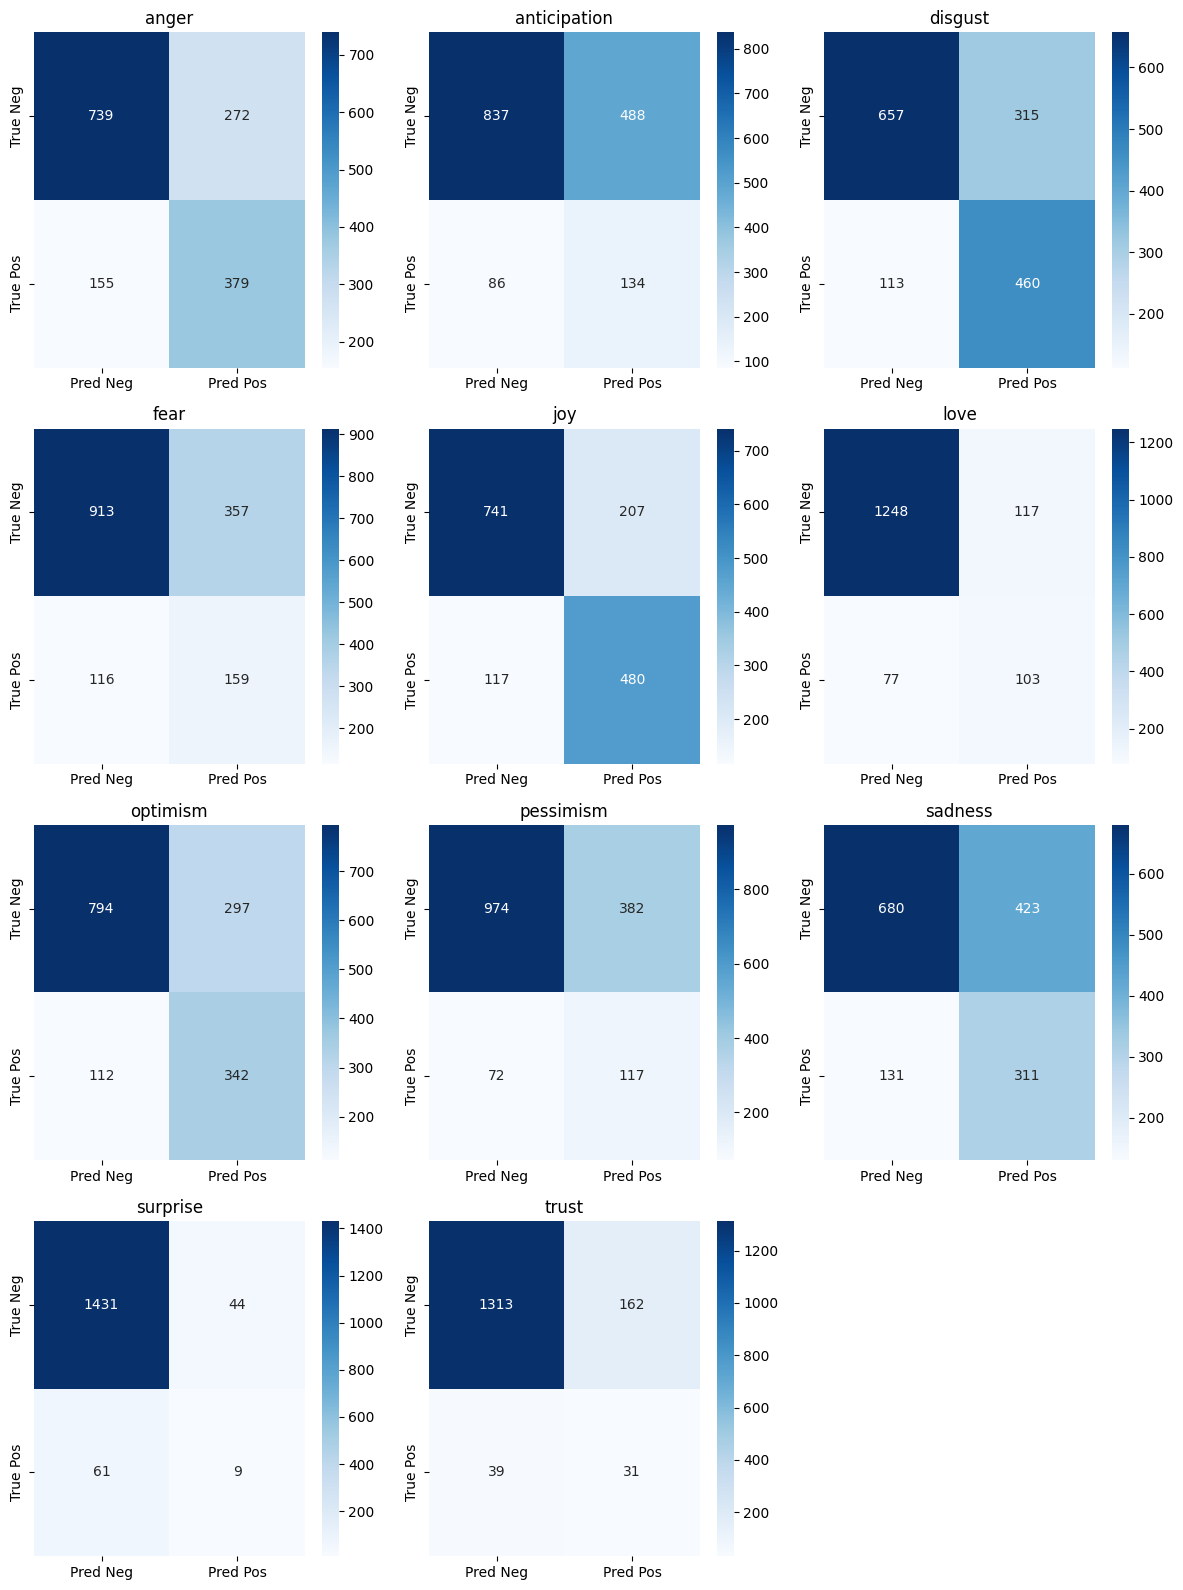

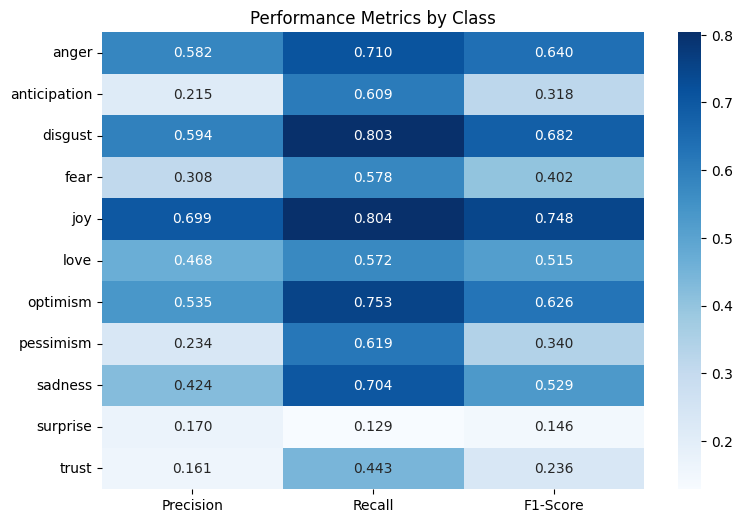

<Figure size 1200x533.333 with 0 Axes>

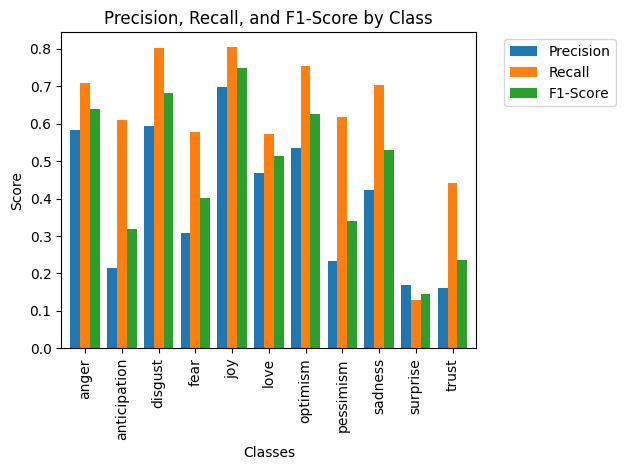

{'macro_avg': {'precision': np.float64(0.39909036815100635),
  'recall': np.float64(0.6112222966878099),
  'f1': np.float64(0.47109476576499854)},
 'per_class': {'Precision': {'anger': 0.5821812596006144,
   'anticipation': 0.21543408360128619,
   'disgust': 0.5935483870967742,
   'fear': 0.3081395348837209,
   'joy': 0.6986899563318777,
   'love': 0.4681818181818182,
   'optimism': 0.5352112676056338,
   'pessimism': 0.23446893787575152,
   'sadness': 0.42370572207084467,
   'surprise': 0.16981132075471697,
   'trust': 0.16062176165803108},
  'Recall': {'anger': 0.7097378277153558,
   'anticipation': 0.6090909090909091,
   'disgust': 0.8027923211169284,
   'fear': 0.5781818181818181,
   'joy': 0.8040201005025126,
   'love': 0.5722222222222222,
   'optimism': 0.7533039647577092,
   'pessimism': 0.6190476190476191,
   'sadness': 0.7036199095022625,
   'surprise': 0.12857142857142856,
   'trust': 0.44285714285714284},
  'F1-Score': {'anger': 0.639662447257384,
   'anticipation': 0.318289

In [65]:
multilabel_evaluation(y_true=valid_labels, y_pred=valid_preds, class_names=class_names, figsize=(12, 8))

<font color = 'indianred'> *Get best checkpoint*</font>


In [66]:
# After training, let us check the best checkpoint
# We need this for Inference
best_model_checkpoint_step = trainer.state.best_model_checkpoint.split('-')[-1]
print(f"The best model was saved at step {best_model_checkpoint_step}.")


The best model was saved at step 120.


<font color = 'indianred'> *Save the  best checkpoint to Huggingface Hub*</font>

In [67]:
# Save the best model checkpoint to Hugging Face Hub
lora_model.push_to_hub(run_name)

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 43.0kB /  665MB            

CommitInfo(commit_url='https://huggingface.co/sayedyounes/stack_exp_ch_gemma_base/commit/5f371ce3469bca06fc17277f17ac25e01084e173', commit_message='Upload model', commit_description='', oid='5f371ce3469bca06fc17277f17ac25e01084e173', pr_url=None, repo_url=RepoUrl('https://huggingface.co/sayedyounes/stack_exp_ch_gemma_base', endpoint='https://huggingface.co', repo_type='model', repo_id='sayedyounes/stack_exp_ch_gemma_base'), pr_revision=None, pr_num=None)

In [68]:
checkpoint = str(model_folder/f'checkpoint-{best_model_checkpoint_step}')
checkpoint

'/content/gemma_lora_imb/checkpoint-120'

In [69]:

# Step 1: Create the repository
repo_id="sayedyounes/stack_exc_multilabel_base_class_head"
create_repo(
    repo_id=repo_id,
    repo_type="model",
    private=False,  # Set to True if you want it private
    exist_ok=True   # Won't error if repo already exists
)

# Step 2: Upload the folder
api = HfApi()
api.upload_folder(
    folder_path=checkpoint,
    repo_id=repo_id,
    repo_type="model",
)


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...eckpoint-120/scheduler.pt: 100%|##########| 1.47kB / 1.47kB            

  ...adapter_model.safetensors:   5%|5         | 33.5MB /  665MB            

  ...point-120/tokenizer.model:   0%|          | 16.2kB / 4.24MB            

  ...ckpoint-120/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  ...kpoint-120/tokenizer.json:  19%|#8        | 6.47MB / 34.4MB            

  ...eckpoint-120/optimizer.pt:   0%|          | 3.99MB / 1.33GB            

  ...int-120/training_args.bin:  42%|####1     | 2.45kB / 5.91kB            

CommitInfo(commit_url='https://huggingface.co/sayedyounes/stack_exc_multilabel_base_class_head/commit/73f00e55bc22f7c5ec8a94aef931f0a93b0120a0', commit_message='Upload folder using huggingface_hub', commit_description='', oid='73f00e55bc22f7c5ec8a94aef931f0a93b0120a0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/sayedyounes/stack_exc_multilabel_base_class_head', endpoint='https://huggingface.co', repo_type='model', repo_id='sayedyounes/stack_exc_multilabel_base_class_head'), pr_revision=None, pr_num=None)

#  <font color = 'indianred'> **7. Performance on Test Set** </font>
For test set evaluation, we will perfrom following steps:



In [71]:
checkpoint="sayedyounes/stack_exc_multilabel_base_class_head"
model = AutoPeftModelForSequenceClassification.from_pretrained(checkpoint,
                                                           num_labels = 11,
                                                           problem_type="multi_label_classification",
                                                           quantization_config=bnb_config,
                                                           torch_dtype=torch_data_type,
                                                           trust_remote_code=True,
)

adapter_config.json: 0.00B [00:00, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some weights of Gemma2ForSequenceClassification were not initialized from the model checkpoint at google/gemma-2-2b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/665M [00:00<?, ?B/s]

In [72]:
peft_config = PeftConfig.from_pretrained(checkpoint)
base_model_name = peft_config.base_model_name_or_path
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

# 3. Set model to evaluation mode
model.eval()

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): Gemma2ForSequenceClassification(
      (model): Gemma2Model(
        (embed_tokens): Embedding(256000, 2304, padding_idx=0)
        (layers): ModuleList(
          (0-25): 26 x Gemma2DecoderLayer(
            (self_attn): Gemma2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2304, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.01, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2304, out_features=128, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=128, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleD

In [73]:
test_set_tokenized = test_split.map(tokenize_fn, batched=True)


Map:   0%|          | 0/1545 [00:00<?, ? examples/s]

In [74]:
test_set_tokenized

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 1545
})

In [75]:
test_set_tokenized.set_format(type='torch')
test_set_tokenized = (test_set_tokenized
          .map(lambda x : {"float_label": x["label"].to(torch.float)}, remove_columns=["label"])
          .rename_column("float_label", "label"))

Map:   0%|          | 0/1545 [00:00<?, ? examples/s]

<font color = 'indianred'>*Training Arguments*</font>

In [76]:
training_args = TrainingArguments(
    seed = 42,
    output_dir="./results",
    per_device_eval_batch_size=16,
    do_train=False,
    do_eval=True,
    report_to=[],
    run_name=run_name
)

<font color = 'indianred'>*Instantiate Trainer*</font>

In [77]:
from functools import partial

In [78]:
compute_metrics_fn = partial(compute_metrics, thresholds=optimal_thresholds)

In [79]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    eval_dataset=test_set_tokenized,
    compute_metrics=compute_metrics_fn,
    tokenizer=tokenizer,
)

/tmp/ipython-input-828365149.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  trainer = CustomTrainer(


<font color = 'indianred'>*Evaluate using Trainer*</font>

In [80]:
free_gpu_memory()

GPU memory has been freed.


In [81]:
test_results= trainer.evaluate()

In [82]:
test_results

{'eval_loss': 1.0061601400375366,
 'eval_model_preparation_time': 0.0051,
 'eval_f1_macro': 0.46477988359042777,
 'eval_runtime': 15.4788,
 'eval_samples_per_second': 99.814,
 'eval_steps_per_second': 6.267}

In [83]:
wandb.log({"test_f1_macro": test_results["eval_f1_macro"]})

<font color = 'indianred'>*Confusion Matrix*</font>

In [84]:
test_output = trainer.predict(test_set_tokenized)

In [85]:
test_preds = np.array((test_output.predictions > 0).astype(int))
test_labels = np.array(test_output.label_ids.astype(int))


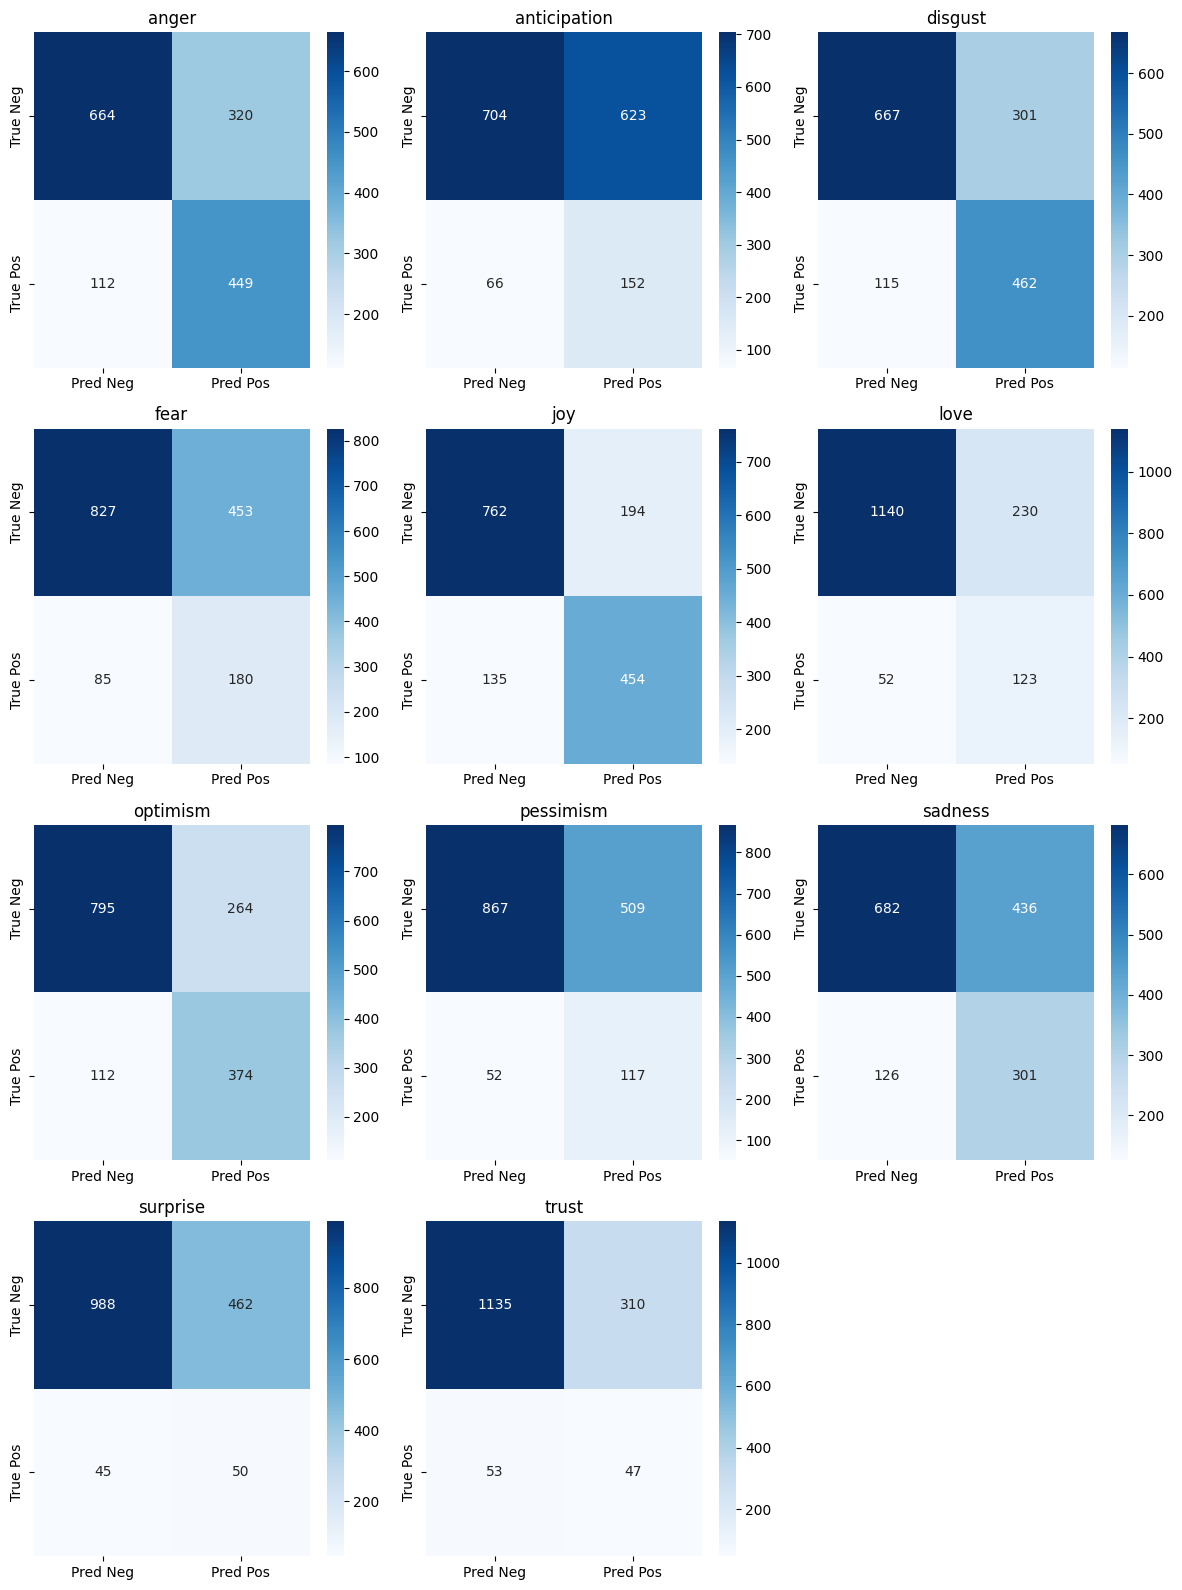

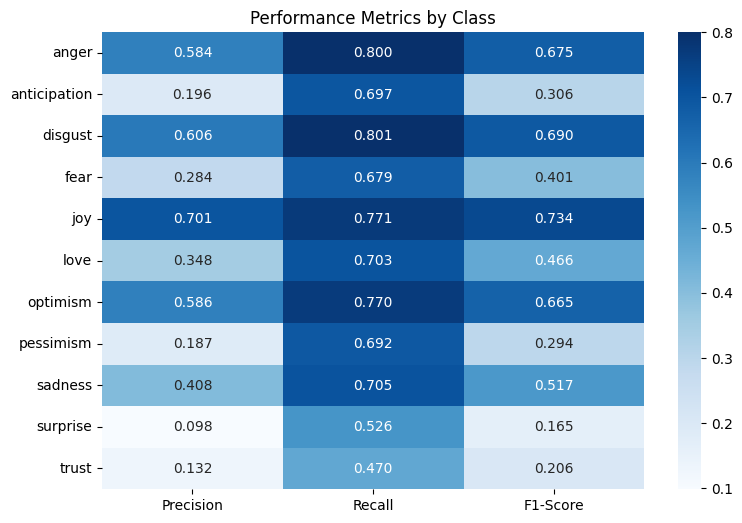

<Figure size 1200x533.333 with 0 Axes>

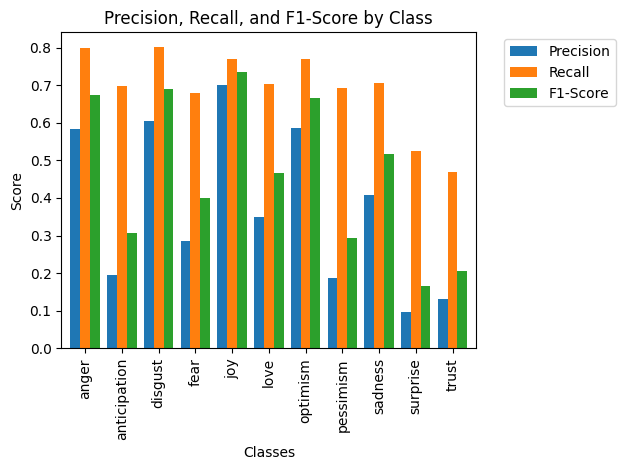

{'macro_avg': {'precision': np.float64(0.3754324937231301),
  'recall': np.float64(0.6922078801598001),
  'f1': np.float64(0.4653775660296811)},
 'per_class': {'Precision': {'anger': 0.5838751625487646,
   'anticipation': 0.19612903225806452,
   'disgust': 0.6055045871559633,
   'fear': 0.2843601895734597,
   'joy': 0.7006172839506173,
   'love': 0.34844192634560905,
   'optimism': 0.5862068965517241,
   'pessimism': 0.1869009584664537,
   'sadness': 0.4084124830393487,
   'surprise': 0.09765625,
   'trust': 0.13165266106442577},
  'Recall': {'anger': 0.8003565062388592,
   'anticipation': 0.6972477064220184,
   'disgust': 0.8006932409012132,
   'fear': 0.6792452830188679,
   'joy': 0.7707979626485568,
   'love': 0.7028571428571428,
   'optimism': 0.7695473251028807,
   'pessimism': 0.6923076923076923,
   'sadness': 0.7049180327868853,
   'surprise': 0.5263157894736842,
   'trust': 0.47},
  'F1-Score': {'anger': 0.675187969924812,
   'anticipation': 0.30614300100704933,
   'disgust': 0

In [86]:
multilabel_evaluation(y_true=test_labels, y_pred=test_preds, class_names=class_names, figsize=(12, 8))

In [87]:
wandb.finish()

eval/f1_macro,▁▃▅▇███
eval/loss,█▄▂▂▁▁▁
eval/runtime,▂▄▂▄▃▁█
eval/samples_per_second,▇▅▇▅▆█▁
eval/steps_per_second,▇▅▇▅▅█▁
eval_f1_macro,▁
eval_loss,▁
test/f1_macro,▁
test/loss,▁
test/runtime,▁
+8,...


# <Font color = 'indianred'> **8. Model Inference**



In [88]:
model = AutoPeftModelForSequenceClassification.from_pretrained(checkpoint,
                                                           num_labels = 11,
                                                           problem_type="multi_label_classification",
                                                           quantization_config=bnb_config,
                                                           torch_dtype=torch_data_type,
                                                           trust_remote_code=True,
)

peft_config = PeftConfig.from_pretrained(checkpoint)
base_model_name = peft_config.base_model_name_or_path
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
# Set model to evaluation mode
model.eval()
model.config.use_cache = False

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some weights of Gemma2ForSequenceClassification were not initialized from the model checkpoint at google/gemma-2-2b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [89]:
model.config

Gemma2Config {
  "architectures": [
    "Gemma2ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": 50.0,
  "bos_token_id": 2,
  "cache_implementation": "hybrid",
  "dtype": "bfloat16",
  "eos_token_id": 1,
  "final_logit_softcapping": 30.0,
  "head_dim": 256,
  "hidden_act": "gelu_pytorch_tanh",
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 2304,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8",
    "9": "LABEL_9",
    "10": "LABEL_10"
  },
  "initializer_range": 0.02,
  "intermediate_size": 9216,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_10": 10,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5,
    "LABEL_6": 6,
    "LABEL_7": 7,
    "LABEL_8": 8,
    "LABEL_9": 9
  },
  "layer_types": [
    "sliding_attention",
    "full_attention",
 

In [90]:
id2label= {id_: label_ for id_, label_ in enumerate(class_names)}
label2id = {label_: id_ for id_, label_ in enumerate(class_names)}
model.config.id2label = id2label
model.config.label2id = label2id

In [91]:
custom_pipeline = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    top_k=None,
    function_to_apply='sigmoid',
    max_length=512,
    truncation=True)

Device set to use cuda:0


<font color = 'indianred'> **Test the pipeline on a single example**

In [92]:
sample = test_split['text'][0]
preds = custom_pipeline(sample)
preds


[[{'label': 'joy', 'score': 0.9381240010261536},
  {'label': 'optimism', 'score': 0.8519527316093445},
  {'label': 'love', 'score': 0.7839884757995605},
  {'label': 'surprise', 'score': 0.7041601538658142},
  {'label': 'trust', 'score': 0.6766198873519897},
  {'label': 'anticipation', 'score': 0.23792988061904907},
  {'label': 'sadness', 'score': 0.2018132209777832},
  {'label': 'fear', 'score': 0.16995622217655182},
  {'label': 'disgust', 'score': 0.103748619556427},
  {'label': 'pessimism', 'score': 0.08509904891252518},
  {'label': 'anger', 'score': 0.023330770432949066}]]

In [93]:
def get_positive_labels(pipeline_output, optimal_thresholds):

   positive_labels = []

   for pred_set in pipeline_output:
       # Get scores for all labels
       scores = [pred['score'] for pred in pred_set]
       labels = [pred['label'] for pred in pred_set]

       # Get positions where score > threshold for that label
       sample_positives = [
           label for label, score, threshold in zip(labels, scores, optimal_thresholds)
           if score >= threshold
       ]

       positive_labels.append(sample_positives)

   return positive_labels


In [94]:
results = get_positive_labels(preds, optimal_thresholds)
results

[['joy', 'optimism', 'love', 'surprise', 'trust']]

<font color = 'indianred'> **Test the pipeline on a large dataset**

In [95]:
free_gpu_memory()

GPU memory has been freed.


In [96]:
def predict_batch(examples):
    return {'predictions': custom_pipeline(examples['text'])}


results = test_split.select(range(100)).map(
    predict_batch,
    batched=True,
    batch_size=32,

)

predictions = results['predictions']

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [97]:
predictions[0:3]

[[{'label': 'joy', 'score': 0.9381240010261536},
  {'label': 'optimism', 'score': 0.8519527316093445},
  {'label': 'love', 'score': 0.7839884757995605},
  {'label': 'surprise', 'score': 0.7041601538658142},
  {'label': 'trust', 'score': 0.6766198873519897},
  {'label': 'anticipation', 'score': 0.23792988061904907},
  {'label': 'sadness', 'score': 0.2018132209777832},
  {'label': 'fear', 'score': 0.16995622217655182},
  {'label': 'disgust', 'score': 0.103748619556427},
  {'label': 'pessimism', 'score': 0.08509904891252518},
  {'label': 'anger', 'score': 0.023330770432949066}],
 [{'label': 'joy', 'score': 0.6406359076499939},
  {'label': 'disgust', 'score': 0.5607337951660156},
  {'label': 'anger', 'score': 0.5026244521141052},
  {'label': 'anticipation', 'score': 0.44167301058769226},
  {'label': 'optimism', 'score': 0.43638181686401367},
  {'label': 'surprise', 'score': 0.36026397347450256},
  {'label': 'fear', 'score': 0.3459886312484741},
  {'label': 'trust', 'score': 0.3208212852478

In [98]:
results = get_positive_labels(predictions, optimal_thresholds)
results[0:3]

[['joy', 'optimism', 'love', 'surprise', 'trust'],
 ['joy', 'anger'],
 ['anticipation', 'optimism', 'joy', 'love', 'trust']]

##Kaggle Submission Code

In [99]:
test_kaggle_df = pd.read_csv(data_folder/'test.csv')


test_kaggle_dataset = Dataset.from_dict({
    'text': test_kaggle_df['Tweet'].tolist()
})


test_kaggle_tokenized = test_kaggle_dataset.map(tokenize_fn, batched=True)
test_kaggle_tokenized.set_format(type='torch')

test_kaggle_output = trainer.predict(test_kaggle_tokenized)
test_kaggle_logits = test_kaggle_output.predictions
test_kaggle_probs = sigmoid(test_kaggle_logits)


test_kaggle_preds = (test_kaggle_probs > optimal_thresholds).astype(int)


sub = pd.DataFrame({
    'ID': test_kaggle_df['ID']
})

for i, emotion in enumerate(class_names):
    sub[emotion] = test_kaggle_preds[:, i]


submission_path = model_folder/'ssub_partA.csv'
sub.to_csv(submission_path, index=False)


!head -n 10 {submission_path}




Map:   0%|          | 0/3259 [00:00<?, ? examples/s]

ID,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust
2018-01559,0,0,0,1,0,0,1,0,0,0,0
2018-03739,1,0,1,1,0,0,1,0,0,0,0
2018-00385,0,0,1,1,0,0,0,1,1,0,0
2018-03001,0,0,1,1,0,0,0,1,1,0,0
2018-01988,0,0,0,0,0,0,1,1,0,0,0
2018-03463,1,0,1,0,1,0,0,0,0,1,0
2018-04315,0,1,0,0,1,0,1,0,0,0,0
2018-01426,0,1,0,0,1,0,1,0,1,0,0
2018-03332,1,1,0,1,1,0,1,1,0,0,0


In [100]:
comp = 'emotion-detection-fall-2025-dl'
submission_message = 'Part A'

!kaggle competitions submit -c {comp} -f {submission_path} -m "{submission_message}"


100% 105k/105k [00:01<00:00, 105kB/s]
Successfully submitted to Emotion Detection Fall 2025 DL